# 홈트레이닝 자세 교정 AI 시스템


## 실행 환경
- **플랫폼**: Kaggle Notebooks (필수)
- **GPU**: Tesla T4 (Accelerator 설정 필수)
- **Python**: 3.12
- **Internet**: ON 설정 필수

## 사전 준비
1. Kaggle Secrets에 API 키 2개 등록
   - `ROBOFLOW_API_KEY`: app.roboflow.com → Settings → API Key
   - `GROQ_API_KEY`: console.groq.com → API Keys → Create Key
2. Add Data에서 COCO 2017 데이터셋 연결
   - 검색: `awsaf49/coco-2017-dataset`
3. 사용자 영상을 Kaggle Dataset으로 업로드 후 연결

## 실행 순서
셀을 위에서 아래로 순서대로 실행

| 셀 | 내용 | 소요시간 |
|---|---|---|
| 셀 1 | 패키지 설치 | 2분 |
| 셀 2 | Import + 상수 정의 | 즉시 |
| 셀 3 | COCO 경로 설정 | 30초 |
| 셀 4 | Roboflow 다운로드 | 2분 |
| 셀 5 | Baseline 모델 로드 | 1분 |
| 셀 6~7 | Pseudo-labeling | 20분 |
| 셀 8~12 | Fine-tuning (10 epoch) | 50분 |
| 셀 13 | 성능 평가 | 1분 |
| 셀 14~17 | 함수 정의 | 즉시 |
| 셀 18 | 최종 테스트 실행 | 5~10분 |

## 최종 테스트 입력값
```python
analyze_full(
    youtube_url     = "유튜브 링크",
    user_video_path = "/kaggle/input/.../영상.mp4",
    start_time      = 213,  # 운동 시작 시간 (초)
    end_time        = 270,  # 운동 끝 시간 (초)
)
```
ex. 1분 10초면 70으로 작성

## 주의사항
- GPU, Internet 설정 필수
- 셀 순서대로 실행 필수
- 런타임 재시작 시 처음부터 재실행 필요

## 1. 라이브러리 설치 및 Import

In [1]:
# 필요한 패키지 설치
!pip install roboflow groq --break-system-packages -q
!apt-get install -y fonts-nanum -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.9/175.9 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 36.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 100.7 MB/s eta 0:00:0000:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.2.0 which is incompatible.
Reading package lists...
Building dependency tree...
Reading state information...
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 

In [2]:
import os
import json
import copy
import random
import numpy as np
import cv2
import torch
import torchvision
from torchvision.transforms import functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
from tqdm import tqdm
from groq import Groq
from kaggle_secrets import UserSecretsClient

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 장치: {device}")

KEYPOINT_NAMES = [
    'nose', 'L_eye', 'R_eye', 'L_ear', 'R_ear',
    'L_sho', 'R_sho', 'L_elb', 'R_elb',
    'L_wri', 'R_wri', 'L_hip', 'R_hip',
    'L_kne', 'R_kne', 'L_ank', 'R_ank'
]

SKELETON = [
    (5,7),(7,9),
    (6,8),(8,10),
    (5,6),
    (5,11),(6,12),
    (11,12),
    (11,13),(13,15),
    (12,14),(14,16)
]

print("Import 완료!")

사용 장치: cuda
Import 완료!


## 2. 데이터 경로 설정 및 Roboflow 다운로드

In [3]:
# COCO 경로 설정
BASE = '/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017'
ANN_TRAIN = f'{BASE}/annotations/person_keypoints_train2017.json'
ANN_VAL   = f'{BASE}/annotations/person_keypoints_val2017.json'
IMG_TRAIN = f'{BASE}/train2017'
IMG_VAL   = f'{BASE}/val2017'

# COCO 어노테이션 로드
with open(ANN_VAL, 'r') as f:
    coco_val = json.load(f)

print(f"COCO val 이미지 수: {len(coco_val['images'])}")
print(f"COCO val 어노테이션 수: {len(coco_val['annotations'])}")

COCO val 이미지 수: 5000
COCO val 어노테이션 수: 11004


In [6]:
# Roboflow 데이터 다운로드
from roboflow import Roboflow

rf = Roboflow(api_key=UserSecretsClient().get_secret("ROBOFLOW_API_KEY"))
project = rf.workspace("highlight-84ih7").project("exercise-pose")
dataset = project.version(5).download("coco")

RF_BASE = 'Exercise-Pose-5'
RF_TRAIN = f'{RF_BASE}/train'
RF_VALID = f'{RF_BASE}/valid'
RF_TEST  = f'{RF_BASE}/test'

# 어노테이션 로드
with open(f'{RF_TRAIN}/_annotations.coco.json', 'r') as f:
    rf_train = json.load(f)
with open(f'{RF_VALID}/_annotations.coco.json', 'r') as f:
    rf_valid = json.load(f)
with open(f'{RF_TEST}/_annotations.coco.json', 'r') as f:
    rf_test = json.load(f)

print(f"Roboflow train: {len(rf_train['images'])}장")
print(f"Roboflow valid: {len(rf_valid['images'])}장")
print(f"Roboflow test:  {len(rf_test['images'])}장")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Exercise-Pose-5 in coco:: 100%|██████████| 1410/1410 [00:00<00:00, 2357.84it/s]

Roboflow train: 1222장
Roboflow valid: 120장
Roboflow test:  60장


## 3. COCO Pretrained 모델 로드

In [7]:
# COCO pretrained KeypointRCNN 로드
baseline_model = torchvision.models.detection.keypointrcnn_resnet50_fpn(
    weights='DEFAULT'
)
baseline_model = baseline_model.to(device)
baseline_model.eval()
print("Baseline 모델 로드 완료!")

Baseline 모델 로드 완료!


## 4. Pseudo-labeling

COCO pretrained 모델로 Roboflow 이미지에 keypoint를 자동 생성하고
COCO 형식의 어노테이션 JSON으로 저장합니다.

In [8]:
def predict_keypoints(model, img_path, threshold=0.9):
    """이미지에서 keypoint 추출"""
    img_pil = Image.open(img_path).convert('RGB')
    img_tensor = F.to_tensor(img_pil).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_tensor)

    if len(outputs[0]['scores']) == 0:
        return None, None

    # 가장 신뢰도 높은 사람 선택
    scores = outputs[0]['scores']
    best_idx = scores.argmax().item()

    if scores[best_idx].item() < threshold:
        return None, None

    keypoints = outputs[0]['keypoints'][best_idx].cpu().numpy()  # (17, 3)
    bbox = outputs[0]['boxes'][best_idx].cpu().numpy()           # (4,)
    return keypoints, bbox


def pseudo_label_dataset(model, img_dir, ann_data, split_name):
    """Roboflow 이미지에 keypoint 자동 생성 후 COCO 형식으로 저장"""
    new_annotations = []
    ann_id = 0
    success = 0

    print(f"\n[{split_name}] Pseudo-labeling 시작...")
    for img_info in tqdm(ann_data['images']):
        img_path = os.path.join(img_dir, img_info['file_name'])
        if not os.path.exists(img_path):
            continue

        keypoints, bbox = predict_keypoints(model, img_path)
        if keypoints is None:
            continue

        # 기존 어노테이션에서 해당 이미지의 bbox/category 정보 가져오기
        orig_anns = [a for a in ann_data['annotations']
                     if a['image_id'] == img_info['id']]
        if not orig_anns:
            continue

        orig_ann = orig_anns[0]

        # keypoint를 COCO 형식으로 변환 [x, y, v, x, y, v, ...]
        kp_list = []
        for i in range(17):
            x, y, score = keypoints[i]
            v = 2 if score > 0.5 else 0  # 신뢰도 0.5 이상이면 visible
            kp_list.extend([float(x), float(y), int(v)])

        new_ann = {
            'id': ann_id,
            'image_id': img_info['id'],
            'category_id': 1,  # person
            'keypoints': kp_list,
            'num_keypoints': sum(1 for i in range(17) if kp_list[i*3+2] > 0),
            'bbox': orig_ann['bbox'],
            'area': orig_ann['area'],
            'segmentation': [],
            'iscrowd': 0
        }
        new_annotations.append(new_ann)
        ann_id += 1
        success += 1

    # COCO 형식 JSON 생성
    new_data = {
        'info': {'description': f'Pseudo-labeled Exercise Pose {split_name}'},
        'images': ann_data['images'],
        'annotations': new_annotations,
        'categories': [{
            'id': 1,
            'name': 'person',
            'keypoints': KEYPOINT_NAMES,
            'skeleton': [[s+1, e+1] for s, e in SKELETON]
        }]
    }

    save_path = f'{RF_BASE}/{split_name}_pseudo.json'
    with open(save_path, 'w') as f:
        json.dump(new_data, f)

    print(f"[{split_name}] 완료: {success}/{len(ann_data['images'])}장 성공")
    print(f"저장: {save_path}")
    return new_data


# Pseudo-labeling 실행
pseudo_train = pseudo_label_dataset(baseline_model, RF_TRAIN, rf_train, 'train')
pseudo_valid = pseudo_label_dataset(baseline_model, RF_VALID, rf_valid, 'valid')
pseudo_test  = pseudo_label_dataset(baseline_model, RF_TEST,  rf_test,  'test')


[train] Pseudo-labeling 시작...


100%|██████████| 1222/1222 [03:54<00:00,  5.22it/s]


[train] 완료: 1222/1222장 성공
저장: Exercise-Pose-5/train_pseudo.json

[valid] Pseudo-labeling 시작...


100%|██████████| 120/120 [00:23<00:00,  5.05it/s]


[valid] 완료: 119/120장 성공
저장: Exercise-Pose-5/valid_pseudo.json

[test] Pseudo-labeling 시작...


100%|██████████| 60/60 [00:11<00:00,  5.10it/s]


[test] 완료: 60/60장 성공
저장: Exercise-Pose-5/test_pseudo.json


## 5. Fine-tuning

In [9]:
class ExerciseKeypointDataset(Dataset):
    """Pseudo-labeled 운동 자세 데이터셋"""

    def __init__(self, img_dir, ann_data):
        self.img_dir = img_dir
        self.images = ann_data['images']
        self.annotations = {a['image_id']: a for a in ann_data['annotations']}

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_info = self.images[idx]
        img_id = img_info['id']

        # 이미지 로드
        img_path = os.path.join(self.img_dir, img_info['file_name'])
        img = Image.open(img_path).convert('RGB')
        img_tensor = F.to_tensor(img)

        if img_id not in self.annotations:
            return img_tensor, None

        ann = self.annotations[img_id]

        # bbox
        x, y, w, h = ann['bbox']
        boxes = torch.tensor([[x, y, x+w, y+h]], dtype=torch.float32)

        # keypoints (17, 3) → (1, 17, 3)
        kps = ann['keypoints']
        keypoints = torch.tensor(
            [[kps[i*3], kps[i*3+1], kps[i*3+2]] for i in range(17)],
            dtype=torch.float32
        ).unsqueeze(0)

        target = {
            'boxes': boxes,
            'labels': torch.tensor([1], dtype=torch.int64),
            'keypoints': keypoints,
            'image_id': torch.tensor([img_id])
        }
        return img_tensor, target


def collate_fn(batch):
    imgs, targets = zip(*batch)
    imgs = list(imgs)
    targets = [t for t in targets if t is not None]
    return imgs, targets

In [10]:
# 데이터로더 생성
train_dataset = ExerciseKeypointDataset(RF_TRAIN, pseudo_train)
valid_dataset = ExerciseKeypointDataset(RF_VALID, pseudo_valid)

train_loader = DataLoader(train_dataset, batch_size=4,
                          shuffle=True, collate_fn=collate_fn)
valid_loader = DataLoader(valid_dataset, batch_size=4,
                          shuffle=False, collate_fn=collate_fn)

print(f"Train: {len(train_dataset)}장")
print(f"Valid: {len(valid_dataset)}장")

Train: 1222장
Valid: 120장


In [11]:
# Fine-tuning 모델 준비
ft_model = torchvision.models.detection.keypointrcnn_resnet50_fpn(
    weights='DEFAULT'
)

# Backbone + FPN freeze (마지막 레이어만 학습)
for name, param in ft_model.named_parameters():
    if 'backbone' in name or 'fpn' in name:
        param.requires_grad = False

ft_model = ft_model.to(device)

# 학습 가능한 파라미터 수 확인
trainable = sum(p.numel() for p in ft_model.parameters() if p.requires_grad)
total = sum(p.numel() for p in ft_model.parameters())
print(f"학습 파라미터: {trainable:,} / 전체: {total:,}")

optimizer = torch.optim.SGD(
    [p for p in ft_model.parameters() if p.requires_grad],
    lr=0.005, momentum=0.9, weight_decay=0.0005
)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

학습 파라미터: 32,337,962 / 전체: 59,137,258


In [12]:
# Fine-tuning 학습
NUM_EPOCHS = 10
train_losses = []

print("Fine-tuning 시작!")
for epoch in range(NUM_EPOCHS):
    ft_model.train()
    epoch_loss = 0
    count = 0

    for imgs, targets in tqdm(train_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS}'):
        if len(targets) == 0:
            continue

        imgs = [img.to(device) for img in imgs[:len(targets)]]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = ft_model(imgs, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        epoch_loss += losses.item()
        count += 1

    avg_loss = epoch_loss / max(count, 1)
    train_losses.append(avg_loss)
    scheduler.step()
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {avg_loss:.4f}")

print("\nFine-tuning 완료!")
torch.save(ft_model.state_dict(), 'finetuned_keypointrcnn.pth')
print("모델 저장: finetuned_keypointrcnn.pth")

Fine-tuning 시작!


Epoch 1/10: 100%|██████████| 306/306 [04:50<00:00,  1.06it/s]


Epoch 1/10 | Loss: 1.5374


Epoch 2/10: 100%|██████████| 306/306 [04:47<00:00,  1.06it/s]


Epoch 2/10 | Loss: 1.4196


...

Epoch 8/10 | Loss: 1.0145


Epoch 9/10: 100%|██████████| 306/306 [04:42<00:00,  1.08it/s]


Epoch 9/10 | Loss: 1.0029


Epoch 10/10: 100%|██████████| 306/306 [04:42<00:00,  1.08it/s]


Epoch 10/10 | Loss: 1.0064

Fine-tuning 완료!
모델 저장: finetuned_keypointrcnn.pth


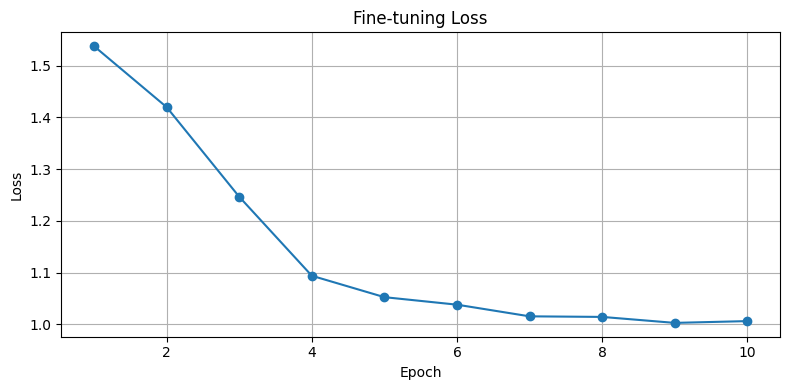

In [13]:
# 학습 손실 시각화
plt.figure(figsize=(8, 4))
plt.plot(range(1, NUM_EPOCHS+1), train_losses, marker='o')
plt.title('Fine-tuning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.tight_layout()
plt.show()

## 6. 성능 평가 (Baseline vs Fine-tuned)

In [14]:
def calc_pck(pred_kps, gt_kps, threshold=0.2):
    """
    PCK (Percentage of Correct Keypoints) 계산
    - 예측 keypoint가 정답 keypoint로부터
      사람 크기(torso_size) * threshold 이내면 correct
    """
    l_sho = np.array(gt_kps[5][:2])
    r_sho = np.array(gt_kps[6][:2])
    l_hip = np.array(gt_kps[11][:2])
    r_hip = np.array(gt_kps[12][:2])
    torso_size = max(
        np.linalg.norm(l_sho - l_hip),
        np.linalg.norm(r_sho - r_hip),
        1.0
    )
    correct = 0
    total = 0
    for i in range(17):
        if gt_kps[i][2] == 0:
            continue
        dist = np.linalg.norm(
            np.array(pred_kps[i][:2]) - np.array(gt_kps[i][:2])
        )
        if dist <= threshold * torso_size:
            correct += 1
        total += 1
    return correct / total if total > 0 else 0


def evaluate_model(model, model_name):
    """pseudo_test 기준으로 fine-tuned 모델 성능 평가"""
    model.eval()
    pck_scores = []

    print(f"\n[{model_name}] 평가 중...")
    for ann in tqdm(pseudo_test['annotations']):
        img_id = ann['image_id']
        img_info = next((i for i in pseudo_test['images']
                         if i['id'] == img_id), None)
        if img_info is None:
            continue

        img_path = os.path.join(RF_TEST, img_info['file_name'])
        if not os.path.exists(img_path):
            continue

        gt_kps_flat = ann['keypoints']
        gt_kps = [[gt_kps_flat[i*3], gt_kps_flat[i*3+1], gt_kps_flat[i*3+2]]
                  for i in range(17)]

        pred_kps, _ = predict_keypoints(model, img_path, threshold=0.5)
        if pred_kps is None:
            continue

        pred_kps_list = [[float(pred_kps[i][0]),
                          float(pred_kps[i][1]),
                          float(pred_kps[i][2])] for i in range(17)]

        pck = calc_pck(pred_kps_list, gt_kps)
        pck_scores.append(pck)

    mean_pck = np.mean(pck_scores) if pck_scores else 0
    print(f"[{model_name}] PCK@0.2: {mean_pck:.4f} ({mean_pck*100:.1f}%)")
    return mean_pck


# fine-tuned 모델만 평가
ft_pck = evaluate_model(ft_model, 'Fine-tuned')
print(f"\n=== 최종 성능 ===")
print(f"Fine-tuned PCK@0.2: {ft_pck*100:.1f}%")


[Fine-tuned] 평가 중...


100%|██████████| 60/60 [00:10<00:00,  5.75it/s]

[Fine-tuned] PCK@0.2: 0.9578 (95.8%)

=== 최종 성능 ===
Fine-tuned PCK@0.2: 95.8%


## 7. 각도 계산 + Good/Bad 판별

In [15]:
def calc_angle(a, b, c):
    """b를 꼭짓점으로 하는 a-b-c 각도 계산 (0~180도)"""
    ba = np.array(a) - np.array(b)
    bc = np.array(c) - np.array(b)
    cosine = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-6)
    return np.degrees(np.arccos(np.clip(cosine, -1.0, 1.0)))


def classify_exercise(keypoints):
    """몸통 기울기로 스쿼트/푸시업 자동 판별"""
    kp = keypoints[:, :2]
    shoulder_y = (kp[5][1] + kp[6][1]) / 2
    hip_y      = (kp[11][1] + kp[12][1]) / 2
    ankle_y    = (kp[15][1] + kp[16][1]) / 2
    ratio = abs(shoulder_y - hip_y) / (abs(shoulder_y - ankle_y) + 1e-6)
    return 'pushup' if ratio < 0.3 else 'squat'


def get_squat_angles(kp):
    return {
        'left_knee':           calc_angle(kp[11], kp[13], kp[15]),
        'right_knee':          calc_angle(kp[12], kp[14], kp[16]),
        'left_hip':            calc_angle(kp[5],  kp[11], kp[13]),
        'right_hip':           calc_angle(kp[6],  kp[12], kp[14]),
        'shoulder_balance':    abs(kp[5][1] - kp[6][1]),
        'left_knee_align':     abs(kp[13][0] - kp[15][0]),
        'right_knee_align':    abs(kp[14][0] - kp[16][0]),
    }


def get_pushup_angles(kp):
    return {
        'left_elbow':   calc_angle(kp[5],  kp[7],  kp[9]),
        'right_elbow':  calc_angle(kp[6],  kp[8],  kp[10]),
        'body_line':    calc_angle(kp[5],  kp[11], kp[15]),
        'wrist_width':    abs(kp[9][0]  - kp[10][0]),
        'shoulder_width': abs(kp[5][0]  - kp[6][0]),
    }


SQUAT_RULES = {
    'left_knee':        (70, 100),
    'right_knee':       (70, 100),
    'left_hip':         (30, 50),
    'right_hip':        (30, 50),
    'shoulder_balance': (0, 15),
    'left_knee_align':  (0, 25),
    'right_knee_align': (0, 25),
}

PUSHUP_RULES = {
    'left_elbow':  (80, 100),
    'right_elbow': (80, 100),
    'body_line':   (165, 180),
}

SQUAT_FEEDBACK = {
    'left_knee':        ('무릎을 더 굽혀주세요', '무릎이 너무 깊어요'),
    'right_knee':       ('무릎을 더 굽혀주세요', '무릎이 너무 깊어요'),
    'left_hip':         ('허리를 더 세워주세요', '엉덩이를 뒤로 빼주세요'),
    'right_hip':        ('허리를 더 세워주세요', '엉덩이를 뒤로 빼주세요'),
    'shoulder_balance': ('어깨가 기울어졌어요', None),
    'left_knee_align':  ('왼쪽 무릎이 안으로 쏠려요', None),
    'right_knee_align': ('오른쪽 무릎이 안으로 쏠려요', None),
}

PUSHUP_FEEDBACK = {
    'left_elbow':  ('팔꿈치를 더 굽혀주세요', '너무 내려갔어요'),
    'right_elbow': ('팔꿈치를 더 굽혀주세요', '너무 내려갔어요'),
    'body_line':   ('엉덩이를 내려주세요', None),
}


def evaluate_pose(keypoints):
    """자세 Good/Bad 판별 + 문제 부위 반환"""
    kp = keypoints[:, :2]
    exercise = classify_exercise(keypoints)

    angles = get_squat_angles(kp) if exercise == 'squat' \
             else get_pushup_angles(kp)
    rules   = SQUAT_RULES    if exercise == 'squat' else PUSHUP_RULES
    feedback_map = SQUAT_FEEDBACK if exercise == 'squat' else PUSHUP_FEEDBACK

    issues = []
    for key, (low, high) in rules.items():
        val = angles[key]
        if val < low and feedback_map[key][0]:
            issues.append({'joint': key, 'value': val,
                           'message': feedback_map[key][0]})
        elif val > high and feedback_map[key][1]:
            issues.append({'joint': key, 'value': val,
                           'message': feedback_map[key][1]})

    overall = 'Good' if len(issues) == 0 else 'Bad'
    return exercise, overall, angles, issues


print("각도 계산 + 판별 함수 정의 완료!")

각도 계산 + 판별 함수 정의 완료!


## 8. LLM 피드백 생성 (Groq)

In [16]:
groq_client = Groq(
    api_key=UserSecretsClient().get_secret("GROQ_API_KEY")
)

def generate_feedback(exercise, overall, issues):
    """Groq LLaMA3로 자세 교정 피드백 생성"""
    if overall == 'Good':
        return "자세가 완벽해요! 이 상태를 유지하세요!"

    issue_summary = "\n".join([
        f"- {i['joint']}: {i['value']:.1f}도 → {i['message']}"
        for i in issues
    ])

    prompt = f"""운동: {exercise}
자세 판정: {overall}
문제 부위:
{issue_summary}

위 분석을 바탕으로 운동하는 사람에게 구체적이고 친절한 자세 교정 피드백을
한국어로만 3문장 이내로 작성해주세요.
반드시 한국어만 사용하고 한자나 영어는 절대 포함하지 마세요."""

    response = groq_client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=200
    )
    return response.choices[0].message.content


print("LLM 피드백 함수 정의 완료!")

LLM 피드백 함수 정의 완료!


## 9. 최종 시각화 + 통합 분석 함수

In [17]:
def visualize_result(img_path, keypoints, issues):
    """문제 부위 빨간 관절선 시각화"""
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 이름 매핑 추가
    joint_to_kp = {
        'left_knee': 'L_kne', 'right_knee': 'R_kne',
        'left_hip': 'L_hip', 'right_hip': 'R_hip',
        'left_elbow': 'L_elb', 'right_elbow': 'R_elb',
        'left_ankle': 'L_ank', 'right_ankle': 'R_ank',
        'shoulder_balance': None,
        'left_knee_align': None, 'right_knee_align': None,
        'body_line': None, 'wrist_width': None, 'shoulder_width': None,
    }

    issue_joints = set()
    for i in issues:
        mapped = joint_to_kp.get(i['joint'])
        if mapped:
            issue_joints.add(mapped)

    points = [(int(keypoints[i][0]), int(keypoints[i][1]), float(keypoints[i][2]))
              for i in range(17)]

    # 연결선 (문제: 빨강 / 정상: 초록)
    for i, j in SKELETON:
        xi, yi, si = points[i]
        xj, yj, sj = points[j]
        if si > 0.5 and sj > 0.5:
            color = (255, 0, 0) if (KEYPOINT_NAMES[i] in issue_joints or
                                    KEYPOINT_NAMES[j] in issue_joints) \
                    else (0, 255, 0)
            cv2.line(img, (xi, yi), (xj, yj), color, 3)

    # 관절 점
    for i in range(17):
        x, y, s = points[i]
        if s > 0.5:
            color = (255, 0, 0) if KEYPOINT_NAMES[i] in issue_joints \
                    else (255, 255, 0)
            cv2.circle(img, (x, y), 7, color, -1)

    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

def analyze(img_path, model=None):
    """이미지 1장 전체 분석 파이프라인"""
    if model is None:
        model = ft_model

    # keypoint 추출
    keypoints, bbox = predict_keypoints(model, img_path, threshold=0.5)
    if keypoints is None:
        print("사람을 찾을 수 없어요.")
        return

    # 자세 평가
    exercise, overall, angles, issues = evaluate_pose(keypoints)

    # LLM 피드백
    feedback = generate_feedback(exercise, overall, issues)

    # 시각화
    visualize_result(img_path, keypoints, issues)

    # 텍스트 결과 출력
    print("=" * 40)
    print(f"운동:  {exercise}")
    print(f"판정:  {overall}")
    print("-" * 40)
    print(f"피드백:\n{feedback}")
    if issues:
        print("-" * 40)
        print("문제 부위:")
        for i in issues:
            print(f"  - {i['joint']}: {i['value']:.1f}° → {i['message']}")
    print("=" * 40)


print("시각화 + 분석 함수 정의 완료!")

시각화 + 분석 함수 정의 완료!


## 10. 테스트

아래 경로에 스쿼트 또는 푸시업 이미지를 넣고 실행하세요.

테스트 이미지: Exercise-Pose-5/test/1608_jpg.rf.08e5aa8475bb50a94f301b264ccfbb9f.jpg


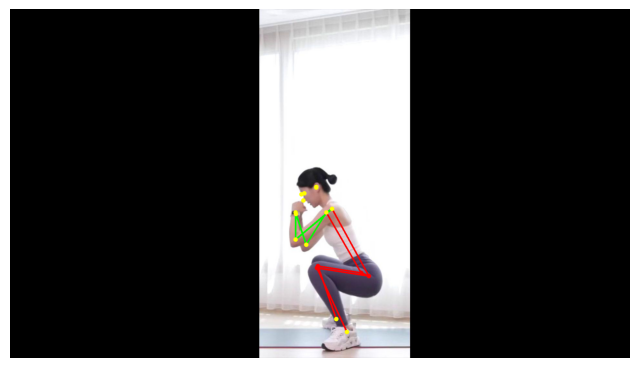

운동:  squat
판정:  Bad
----------------------------------------
피드백:
무릎을 더 굽히고 엉덩이를 뒤로 빼면서 운동하면 더 효과적인 훈련을 할 수 있습니다. 특히 왼쪽 무릎과 오른쪽 무릎을 더 굽혀 주세요. 엉덩이도 뒤로 빼면서 몸 전체의 밸런스를 조절하세요.
----------------------------------------
문제 부위:
  - left_knee: 55.6° → 무릎을 더 굽혀주세요
  - right_knee: 61.5° → 무릎을 더 굽혀주세요
  - left_hip: 52.3° → 엉덩이를 뒤로 빼주세요
  - right_hip: 50.9° → 엉덩이를 뒤로 빼주세요


In [23]:
# Roboflow test 셋에서 샘플 이미지로 테스트
test_img_info = random.choice(rf_test['images'])
test_img_path = f"{RF_TEST}/{test_img_info['file_name']}"

print(f"테스트 이미지: {test_img_path}")
analyze(test_img_path)

In [ ]:
# 본인 사진으로 테스트하려면 아래 경로 수정
# 훈련이 잘 됐는지 성능을 테스트하는 것!
# analyze('/kaggle/working/my_squat.jpg')

In [30]:
!pip install yt-dlp scikit-learn -q

import yt_dlp
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np

# ── 유튜브 영상 다운로드 ─────────────────────────
def download_youtube(url, start_time=None, end_time=None):
    ydl_opts = {
        'outtmpl': '/kaggle/working/reference_video.%(ext)s',
        'format': 'mp4/best[height<=480]',
        'quiet': True,
    }
    if start_time is not None and end_time is not None:
        ydl_opts['download_ranges'] = lambda info, _: [
            {'start_time': start_time, 'end_time': end_time}
        ]
        ydl_opts['force_keyframes_at_cuts'] = True

    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        ydl.download([url])

    for f in os.listdir('/kaggle/working'):
        if f.startswith('reference_video'):
            return f'/kaggle/working/{f}'
    return None


# ── 영상에서 0.5초 단위 프레임 추출 ────────────
def extract_frames(video_path, interval=0.5):
    """0.5초마다 프레임 추출, (frame, timestamp) 리스트 반환"""
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    step = max(int(fps * interval), 1)
    frames = []
    frame_idx = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        if frame_idx % step == 0:
            timestamp = frame_idx / fps
            frames.append((frame, timestamp))
        frame_idx += 1

    cap.release()
    print(f"  총 {len(frames)}개 프레임 추출 ({interval}초 간격)")
    return frames


# ── 프레임에서 관절 각도 벡터 추출 ─────────────
def frame_to_angle_vector(frame):
    """프레임 → 11개 각도 벡터 반환, 실패시 None"""
    tmp = '/kaggle/working/tmp_frame.jpg'
    cv2.imwrite(tmp, frame)

    keypoints, _ = predict_keypoints(ft_model, tmp, threshold=0.5)
    if keypoints is None:
        return None

    kp = keypoints[:, :2]
    vec = np.array([
        calc_angle(kp[11], kp[13], kp[15]),  # left_knee
        calc_angle(kp[12], kp[14], kp[16]),  # right_knee
        calc_angle(kp[5],  kp[11], kp[13]),  # left_hip
        calc_angle(kp[6],  kp[12], kp[14]),  # right_hip
        calc_angle(kp[5],  kp[7],  kp[9]),   # left_elbow
        calc_angle(kp[6],  kp[8],  kp[10]),  # right_elbow
        calc_angle(kp[7],  kp[5],  kp[11]),  # left_shoulder
        calc_angle(kp[8],  kp[6],  kp[12]),  # right_shoulder
        calc_angle(kp[13], kp[15], kp[16]),  # left_ankle
        calc_angle(kp[14], kp[16], kp[15]),  # right_ankle
        calc_angle(kp[5],  kp[11], kp[15]),  # body_line
    ])
    return vec


ANGLE_NAMES = [
    'left_knee', 'right_knee', 'left_hip', 'right_hip',
    'left_elbow', 'right_elbow', 'left_shoulder', 'right_shoulder',
    'left_ankle', 'right_ankle', 'body_line'
]


# ── 시퀀스 클러스터링으로 주요 동작 2개 추출 ────
def extract_main_poses(frames, n_clusters=2):
    """
    프레임들을 클러스터링해서 가장 많이 등장하는
    동작 2개의 대표 각도 반환
    """
    print(f"  각도 벡터 추출 중...")
    vectors = []
    valid_frames = []

    for frame, ts in frames:
        vec = frame_to_angle_vector(frame)
        if vec is not None:
            vectors.append(vec)
            valid_frames.append((frame, ts, vec))

    if len(vectors) < n_clusters:
        print(f"  유효 프레임 부족: {len(vectors)}개")
        return None

    print(f"  유효 프레임: {len(vectors)}개 → 클러스터링...")

    # 정규화 + KMeans 클러스터링
    scaler = StandardScaler()
    X = scaler.fit_transform(np.array(vectors))
    km = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = km.fit_predict(X)

    # 클러스터별 분석
    poses = {}
    for cluster_id in range(n_clusters):
        mask = labels == cluster_id
        cluster_vecs = np.array(vectors)[mask]
        cluster_frames = [valid_frames[i] for i in range(len(valid_frames)) if mask[i]]

        # 대표 각도 = 클러스터 평균
        mean_vec = cluster_vecs.mean(axis=0)

        # 대표 프레임 = 클러스터 중심에 가장 가까운 프레임
        center = km.cluster_centers_[cluster_id]
        X_cluster = X[mask]
        dists = np.linalg.norm(X_cluster - center, axis=1)
        best_idx = dists.argmin()
        best_frame, best_ts, _ = cluster_frames[best_idx]

        poses[cluster_id] = {
            'mean_angles': dict(zip(ANGLE_NAMES, mean_vec)),
            'count': int(mask.sum()),
            'best_frame': best_frame,
            'best_ts': best_ts,
        }
        print(f"  클러스터 {cluster_id}: {mask.sum()}개 프레임 "
              f"(대표 시간: {best_ts:.1f}초)")

    return poses


# ── 사용자 영상에서 고점 프레임 추출 ────────────
def extract_user_peak_frames(frames, n_clusters=2):
    """
    사용자 영상에서 주요 동작 2개의
    '고점' 프레임(가장 극단적인 자세) 반환
    """
    print("  사용자 동작 분석 중...")
    vectors = []
    valid_frames = []

    for frame, ts in frames:
        vec = frame_to_angle_vector(frame)
        if vec is not None:
            vectors.append(vec)
            valid_frames.append((frame, ts, vec))

    if len(vectors) < n_clusters:
        return None

    scaler = StandardScaler()
    X = scaler.fit_transform(np.array(vectors))
    km = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = km.fit_predict(X)

    user_poses = {}
    for cluster_id in range(n_clusters):
        mask = labels == cluster_id
        cluster_frames = [valid_frames[i] for i in range(len(valid_frames)) if mask[i]]
        cluster_vecs = np.array(vectors)[mask]

        # 고점 = 무릎/엉덩이 각도가 가장 작은 프레임 (가장 깊이 앉은 자세)
        knee_angles = cluster_vecs[:, 0]  # left_knee
        peak_idx = knee_angles.argmin()
        peak_frame, peak_ts, peak_vec = cluster_frames[peak_idx]

        user_poses[cluster_id] = {
            'angles': dict(zip(ANGLE_NAMES, cluster_vecs[peak_idx])),
            'count': int(mask.sum()),
            'peak_frame': peak_frame,
            'peak_ts': peak_ts,
            'mean_angles': dict(zip(ANGLE_NAMES, cluster_vecs.mean(axis=0))),
        }
        print(f"  클러스터 {cluster_id}: {mask.sum()}개 프레임 "
              f"(고점 시간: {peak_ts:.1f}초)")

    return user_poses


# ── 동작 매칭 ────────────────────────────────────
def match_poses(ref_poses, user_poses):
    """
    기준 동작 2개 ↔ 사용자 동작 2개를
    각도 벡터 유사도로 매칭
    """
    ref_vecs  = np.array([list(ref_poses[i]['mean_angles'].values())
                          for i in range(len(ref_poses))])
    user_vecs = np.array([list(user_poses[i]['mean_angles'].values())
                          for i in range(len(user_poses))])

    # 유클리드 거리로 매칭
    matches = {}
    used = set()
    for r_id in range(len(ref_poses)):
        best_u, best_dist = None, float('inf')
        for u_id in range(len(user_poses)):
            if u_id in used:
                continue
            dist = np.linalg.norm(ref_vecs[r_id] - user_vecs[u_id])
            if dist < best_dist:
                best_dist = dist
                best_u = u_id
        matches[r_id] = best_u
        used.add(best_u)
        print(f"  기준 동작 {r_id} ↔ 사용자 동작 {best_u} "
              f"(각도 차이: {best_dist:.1f})")

    return matches


# ── 동작별 피드백 생성 ───────────────────────────
def generate_pose_feedback(ref_angles, user_angles, tolerance=15):
    """기준 vs 사용자 각도 비교 → 문제 부위 + LLM 피드백"""
    issues = []
    for key in ANGLE_NAMES:
        if key not in ref_angles or key not in user_angles:
            continue
        diff = user_angles[key] - ref_angles[key]
        if abs(diff) > tolerance:
            issues.append({
                'joint': key,
                'my_value': user_angles[key],
                'ref_value': ref_angles[key],
                'diff': diff,
            })

    overall = 'Good' if len(issues) == 0 else 'Bad'

    if not issues:
        feedback = "자세가 완벽해요! 기준 자세와 일치해요!"
    else:
        issue_summary = "\n".join([
            f"- {i['joint']}: 내 각도 {i['my_value']:.1f}° / "
            f"기준 {i['ref_value']:.1f}° (차이: {i['diff']:+.1f}°)"
            for i in issues
        ])
        prompt = f"""다음은 운동 자세 분석 결과입니다.
기준 자세(유튜브 영상)와 비교했을 때 차이가 나는 관절 부위:
{issue_summary}

위 분석을 바탕으로 어떤 운동인지 추론하고,
구체적이고 친절한 자세 교정 피드백을 한국어로만 3문장 이내로 작성해주세요.
반드시 한국어만 사용하세요."""

        response = groq_client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[{"role": "user", "content": prompt}],
            max_tokens=200
        )
        feedback = response.choices[0].message.content

    return overall, issues, feedback


# ── 결과 시각화 ──────────────────────────────────
def visualize_pose_result(ref_frame, user_frame, ref_keypoints, user_keypoints,
                          issues, pose_label, overall, feedback):
    """기준 이미지 + 사용자 이미지 나란히 출력"""

    joint_to_kp = {
        'left_knee': 'L_kne', 'right_knee': 'R_kne',
        'left_hip': 'L_hip', 'right_hip': 'R_hip',
        'left_elbow': 'L_elb', 'right_elbow': 'R_elb',
        'left_shoulder': 'L_sho', 'right_shoulder': 'R_sho',
        'left_ankle': 'L_ank', 'right_ankle': 'R_ank',
        'body_line': None,
    }
    issue_joints = set()
    for i in issues:
        mapped = joint_to_kp.get(i['joint'])
        if mapped:
            issue_joints.add(mapped)

    def draw_skeleton(frame, keypoints, highlight_issues=False):
        img = cv2.cvtColor(frame.copy(), cv2.COLOR_BGR2RGB)
        points = [(int(keypoints[i][0]), int(keypoints[i][1]),
                   float(keypoints[i][2])) for i in range(17)]

        for i, j in SKELETON:
            xi, yi, si = points[i]
            xj, yj, sj = points[j]
            if si > 0.5 and sj > 0.5:
                if highlight_issues and (KEYPOINT_NAMES[i] in issue_joints or
                                         KEYPOINT_NAMES[j] in issue_joints):
                    color = (255, 0, 0)   # 빨강 (문제 부위)
                else:
                    color = (0, 255, 0)   # 초록
                cv2.line(img, (xi, yi), (xj, yj), color, 3)

        for i in range(17):
            x, y, s = points[i]
            if s > 0.5:
                if highlight_issues and KEYPOINT_NAMES[i] in issue_joints:
                    color = (255, 0, 0)
                else:
                    color = (255, 255, 0)
                cv2.circle(img, (x, y), 7, color, -1)
        return img

    # 기준 이미지 (초록만)
    ref_img  = draw_skeleton(ref_frame,  ref_keypoints,  highlight_issues=False)
    # 사용자 이미지 (문제 부위 빨강)
    user_img = draw_skeleton(user_frame, user_keypoints, highlight_issues=True)

    # 같은 높이로 리사이즈
    h = max(ref_img.shape[0], user_img.shape[0])
    def resize_to_height(img, h):
        ratio = h / img.shape[0]
        w = int(img.shape[1] * ratio)
        return cv2.resize(img, (w, h))

    ref_img  = resize_to_height(ref_img, h)
    user_img = resize_to_height(user_img, h)

    # 나란히 출력
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    axes[0].imshow(ref_img)
    axes[0].axis('off')
    axes[0].set_title(f"기준 자세 (동작 {pose_label})", fontsize=13, color='green')

    axes[1].imshow(user_img)
    axes[1].axis('off')
    axes[1].set_title(f"내 자세 (동작 {pose_label}) — {overall}",
                      fontsize=13,
                      color='red' if overall == 'Bad' else 'green')

    plt.tight_layout()
    plt.show()

    # 텍스트 출력
    print("=" * 45)
    print(f"동작 {pose_label} | 판정: {overall}")
    print("-" * 45)
    print(f"피드백:\n{feedback}")
    if issues:
        print("-" * 45)
        print("문제 부위:")
        for i in issues:
            print(f"  {i['joint']}: "
                  f"내 {i['my_value']:.1f}° / "
                  f"기준 {i['ref_value']:.1f}° "
                  f"({i['diff']:+.1f}°)")
    print("=" * 45)


# ── 메인 분석 함수 ───────────────────────────────
def analyze_full(youtube_url, user_video_path, start_time=None, end_time=None):
    """전체 파이프라인 실행"""

    # 1. 유튜브 다운로드
    print("\n[1] 유튜브 영상 다운로드...")
    ref_video = download_youtube(youtube_url, start_time, end_time)
    if ref_video is None:
        print("다운로드 실패!")
        return

    # 2. 기준 영상 프레임 추출
    print("\n[2] 기준 영상 프레임 추출...")
    ref_frames = extract_frames(ref_video, interval=0.5)

    # 3. 기준 동작 2개 추출
    print("\n[3] 기준 동작 클러스터링...")
    ref_poses = extract_main_poses(ref_frames, n_clusters=2)
    if ref_poses is None:
        print("기준 동작 추출 실패!")
        return

    # 4. 사용자 영상 프레임 추출
    print("\n[4] 사용자 영상 프레임 추출...")
    user_frames = extract_frames(user_video_path, interval=0.5)

    # 5. 사용자 동작 2개 추출 (고점)
    print("\n[5] 사용자 동작 추출...")
    user_poses = extract_user_peak_frames(user_frames, n_clusters=2)
    if user_poses is None:
        print("사용자 동작 추출 실패!")
        return

    # 6. 동작 매칭
    print("\n[6] 동작 매칭...")
    matches = match_poses(ref_poses, user_poses)

    # 7. 동작별 피드백
    print("\n[7] 동작별 피드백 생성...\n")
    for ref_id, user_id in matches.items():
        ref_angles = ref_poses[ref_id]['mean_angles']
        user_angles = user_poses[user_id]['angles']
        user_frame  = user_poses[user_id]['peak_frame']
        ref_frame   = ref_poses[ref_id]['best_frame']      # ← 추가

        overall, issues, feedback = generate_pose_feedback(ref_angles, user_angles)

        # 사용자 고점 프레임 keypoint 추출
        tmp_user = '/kaggle/working/tmp_user_peak.jpg'
        cv2.imwrite(tmp_user, user_frame)
        user_keypoints, _ = predict_keypoints(ft_model, tmp_user, threshold=0.5)

        # 기준 대표 프레임 keypoint 추출                    ← 추가
        tmp_ref = '/kaggle/working/tmp_ref_peak.jpg'
        cv2.imwrite(tmp_ref, ref_frame)
        ref_keypoints, _ = predict_keypoints(ft_model, tmp_ref, threshold=0.5)

        if user_keypoints is not None and ref_keypoints is not None:
            visualize_pose_result(
                ref_frame      = ref_frame,
                user_frame     = user_frame,
                ref_keypoints  = ref_keypoints,
                user_keypoints = user_keypoints,
                issues         = issues,
                pose_label     = ref_id + 1,
                overall        = overall,
                feedback       = feedback
            )
        else:
            print(f"동작 {ref_id+1}: keypoint 추출 실패")

    print("\n분석 완료!")


print("함수 정의 완료!")

함수 정의 완료!


In [28]:
import os

path = '/kaggle/input/datasets/hyunseo2/wrong-lunge'
for f in os.listdir(path):
    print(f)

Wrong_lunge.mp4



[1] 유튜브 영상 다운로드...


                             
[2] 기준 영상 프레임 추출...
  총 22개 프레임 추출 (0.5초 간격)

[3] 기준 동작 클러스터링...
  각도 벡터 추출 중...
  유효 프레임: 22개 → 클러스터링...
  클러스터 0: 15개 프레임 (대표 시간: 6.5초)
  클러스터 1: 7개 프레임 (대표 시간: 5.6초)

[4] 사용자 영상 프레임 추출...
  총 15개 프레임 추출 (0.5초 간격)

[5] 사용자 동작 추출...
  사용자 동작 분석 중...
  클러스터 0: 6개 프레임 (고점 시간: 2.5초)
  클러스터 1: 9개 프레임 (고점 시간: 6.5초)

[6] 동작 매칭...
  기준 동작 0 ↔ 사용자 동작 1 (각도 차이: 128.1)
  기준 동작 1 ↔ 사용자 동작 0 (각도 차이: 138.1)

[7] 동작별 피드백 생성...



Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
Glyph 49464 (\N{HANGUL SYLLABLE SE}) missing from font(s) DejaVu Sans.
Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
Glyph 51089 (\N{HANGUL SYLLABLE JAG}) missing from font(s) DejaVu Sans.
Glyph 45236 (\N{HANGUL SYLLABLE NAE}) missing from font(s) DejaVu Sans.
Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
Glyph 49464 (\N{HANGUL SYLLABLE SE}) missing from font(s) DejaVu Sans.
Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
Glyph 51089 (\N{HANGUL SYLLABLE JAG}) missing from font(s) DejaVu Sans.
Glyph 45236 (\N{HANGUL SYLLABLE NAE}) missing from font(s) DejaVu Sa

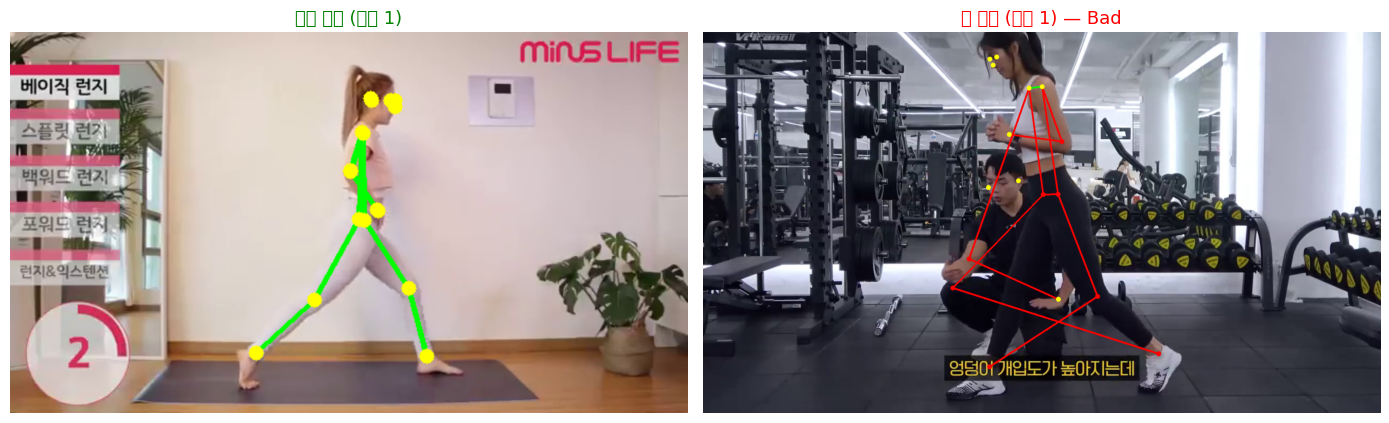

동작 1 | 판정: Bad
---------------------------------------------
피드백:
운동 자세 분석 결과를 바탕으로 추론하면 스쿼트 운동으로 보인다. 무릎과 엉덩이의 각도가 기준 자세와 비교했을 때 상당한 차이를 보이며, 특히 무릎 각도가 낮아 보이는 것으로 보아 스쿼트 동작이 제대로 이루어지지 않고 있다. 이를 개선하기 위해 무릎을 더 구부리고 엉덩이를 뒤로 밀어 스쿼트 자세를 완성하고, 또한 종아리 굽힘 각도를 조절하여 균형을 잡는 것이 중요할 것이다.
---------------------------------------------
문제 부위:
  left_knee: 내 101.8° / 기준 151.7° (-49.9°)
  right_knee: 내 63.5° / 기준 146.4° (-82.9°)
  left_hip: 내 167.2° / 기준 142.2° (+24.9°)
  right_hip: 내 128.2° / 기준 154.4° (-26.2°)
  left_elbow: 내 62.5° / 기준 135.5° (-73.0°)
  right_elbow: 내 94.8° / 기준 128.3° (-33.5°)
  left_ankle: 내 28.5° / 기준 76.5° (-47.9°)
  right_ankle: 내 22.2° / 기준 42.1° (-19.9°)


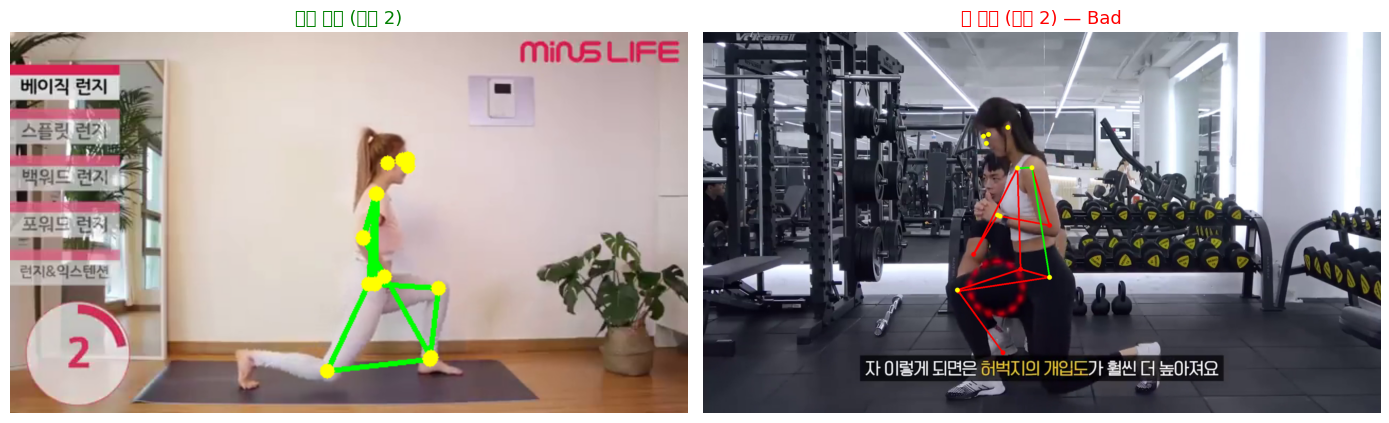

동작 2 | 판정: Bad
---------------------------------------------
피드백:
위 분석 결과를 바탕으로 이 운동은 스쿼트 자세로 추론됩니다. 스쿼트 자세를 교정하기 위해선 좌측 무릎과 종아리, 엉덩이, 및 팔꿈치의 각도를 수정하여 기준 자세와 일치시키는 것이 중요합니다. 자세를 교정하기 위해선 무릎을 더욱 구부리고, 팔을 자연스럽게 편 채로 엉덩이를 내리고 앉는 것을 권장합니다.
---------------------------------------------
문제 부위:
  left_knee: 내 62.9° / 기준 97.2° (-34.3°)
  right_hip: 내 106.6° / 기준 162.3° (-55.7°)
  left_elbow: 내 62.3° / 기준 105.3° (-43.0°)
  right_elbow: 내 4.4° / 기준 109.7° (-105.3°)
  left_ankle: 내 90.0° / 기준 138.3° (-48.3°)
  right_ankle: 내 90.0° / 기준 70.3° (+19.7°)

분석 완료!


In [31]:
# ── 실제 테스트 ──────────────────────────────────

analyze_full(
    youtube_url  = "https://www.youtube.com/watch?v=p0SqT2Qk3cw",   #유튜브 영상 링크
    user_video_path = '/kaggle/input/datasets/hyunseo2/wrong-lunge/Wrong_lunge.mp4',  # 본인 영상
    start_time   = 213,   # 유튜브 영상 운동 시작 시간 (초)
    end_time     = 223,   # 유튜브 영상 운동 끝 시간 (초)
)